# 2023 Kahramanmaraş M7.8

On February 6, 2023, a M7.8 earthquake struck the East Anatolian Fault zone,
causing over 50,000 fatalities across southern Turkiye and Syria.

## 1. Setup

In [1]:
import os, json, shutil, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import xml.etree.ElementTree as ET

EVENT = 'us6000jllz'
os.environ['EVENT'] = EVENT

REPO      = Path('/workspaces/shakemap-gf-workshop')
EVENT_CFG = REPO / 'data/event_configs' / EVENT
EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'

We will be using variations of inputs to run ShakeMaps and need to track the input files between variations.


To help us do this, we use a helper function, check_event_inputs. This allows us to track what inputs are going into the ShakeMap run by showing a check mark if the file exists.

The second helper function uses the gridxml file to compute approximate areas of shaking for different intensities. We will use it to compare results of input variations of the ShakeMap later in the notebook.

In [2]:
def check_event_inputs():
    print('Current event inputs:')
    for f in ['event.xml', 'rupture.json', 'stationlist.json',
              'instrumented_dat.json', 'dyfi_dat.json', 'sites.csv']:
        p = EVENT_DIR / f
        print(f'  {f}: {"✓" if p.exists() else "—"}')

def get_shakemap_stats(gridxml_path):
    tree = ET.parse(gridxml_path)
    root = tree.getroot()
    ns = {'sm': 'http://earthquake.usgs.gov/eqcenter/shakemap'}
    fields = root.findall('sm:grid_field', ns)
    field_names = [f.get('name') for f in fields]
    mmi_idx = field_names.index('MMI')
    spec = root.find('sm:grid_specification', ns)
    dx = float(spec.get('nominal_lon_spacing'))
    dy = float(spec.get('nominal_lat_spacing'))
    cell_area = dx * 111 * dy * 111 * np.cos(np.radians(37))
    data_text = root.find('sm:grid_data', ns).text.strip()
    mmi_vals = [float(line.split()[mmi_idx]) for line in data_text.split('\n') if line.strip()]
    mmi = np.array(mmi_vals)
    return {
        'Max MMI': f'{mmi.max():.1f}',
        'Area MMI≥VII (km²)': f'{(mmi >= 7).sum() * cell_area:,.0f}',
        'Area MMI≥VIII (km²)': f'{(mmi >= 8).sum() * cell_area:,.0f}',
        'Area MMI≥IX (km²)': f'{(mmi >= 9).sum() * cell_area:,.0f}',
    }

## 2. Stage the event

The sm_create module will download ShakeMap input data from USGS Comcat. The files are also available to download and browse on the event page :https://earthquake.usgs.gov/earthquakes/eventpage/us6000jllz/shakemap/intensity.

In [3]:
%%bash
sm_create -h

usage: sm_create [-h] [-f] [-s SOURCE] [-e NETID TIME LON LAT DEP MAG LOCSTR]
                 [--network NETWORK] [-b] [-m] [-n] [-v]
                 eventid

    "Clone" a ShakeMap from NEIC Comcat, or create an event from scratch.

    Notes on usage:

    eventid is a ComCat event ID.  For example, for this event:
    https://earthquake.usgs.gov/earthquakes/eventpage/us2000ar20
    The event ID is us2000ar20.

    If no source is specified, then the event ID used for the event directory,
    eventid field in event.xml file, and names of data and fault files will
    be that of the *authoritative* origin.

    If a source (us, ci, nc, etc.) is specified, then that ID is used instead
    of the authoritative ID.

    

positional arguments:
  eventid               ID of the event to process

options:
  -h, --help            show this help message and exit
  -f, --force           Force overwrite of event data.
  -s SOURCE, --source SOURCE
                        Specify the source ne

In [ ]:
%%bash
export EVENT=us6000jllz
sm_create $EVENT

Wrote 4 files to /home/vscode/shakemap_profiles/default/data/us6000jllz/current:
	dyfi_dat.json
	event.xml
	instrumented_dat.json
	rupture.json


We need to copy the input files because we will be running variations of ShakeMap with different inputs.

In [4]:
shutil.copy(EVENT_CFG / 'event.xml',    EVENT_DIR / 'event.xml')
shutil.copy(EVENT_CFG / 'rupture.json', EVENT_DIR / 'rupture.json')
shutil.copy(EVENT_CFG / 'model.conf',   EVENT_DIR / 'model.conf')
for f in ['stationlist.json', 'instrumented_dat.json', 'dyfi_dat.json']:
    p = EVENT_DIR / f
    if p.exists():
        p.unlink()
        print(f'Removed {f}')
import subprocess
subprocess.run(['shake', EVENT, 'select'], capture_output=True)
print('select done')
check_event_inputs()

select done
Current event inputs:
  event.xml: ✓
  rupture.json: ✓
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


## 3. Grid mode with finite fault

We now will run ShakeMap using the finite fault rupture geometry but no station observations. We use our helper function to confirm the inputs we want to run ShakeMap.

In [6]:
check_event_inputs()

Current event inputs:
  event.xml: ✓
  rupture.json: ✓
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: —


In [7]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid FF no stations' model contour mapping gridxml

INFO -- 2026-08-31 18:30:58 -- shake.main -- Running command assemble
INFO -- 2026-08-31 18:30:58 -- shake.main -- Finished running command assemble: Elapsed 0.07 secs
INFO -- 2026-08-31 18:30:58 -- shake.main -- Running command model
INFO -- 2026-08-31 18:30:58 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:30:58 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:30:58 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 18:30:58 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-31 18:30:58 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-31 18:31:06 -- shake.main -- Finished running command model: Elapsed 7.34 secs
INFO -- 2026-08-31 18:31:06 -- shake.main -- Running command contour
INFO -- 2026-08-31 18:31:07 -- shake.main --

INFO -- 2026-08-31 18:31:28 -- shake.main -- Finished running command mapping: Elapsed 21.13 secs
INFO -- 2026-08-31 18:31:28 -- shake.main -- Running command gridxml
INFO -- 2026-08-31 18:31:29 -- shake.main -- Finished running command gridxml: Elapsed 0.65 secs
INFO -- 2026-08-31 18:31:29 -- shake.main -- shake finished with event us6000jllz


We need to copy the images so that we can compare them to other variations later.

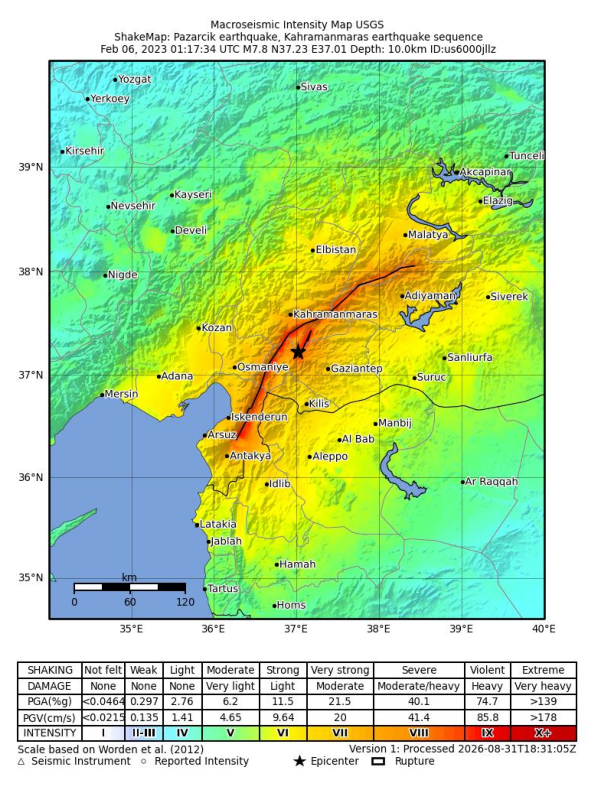

In [ ]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step2_FF_grid.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step2_grid.xml')
step2_products = Path.home() / 'step2_products'
if step2_products.exists(): shutil.rmtree(step2_products)
shutil.copytree(PRODUCTS, step2_products)
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(PRODUCTS / 'intensity.jpg'))
plt.axis('off'); plt.tight_layout(); plt.show()

## 4. Grid mode with point source

We first remove rupture.json from the input files so ShakeMap uses a point source.

In [9]:
rupture = EVENT_DIR / 'rupture.json'
rupture_bak = EVENT_DIR / 'rupture.json.bak'
if rupture.exists():
    rupture.rename(rupture_bak)
    print('rupture.json moved — point source mode')
elif rupture_bak.exists():
    print('Already in point source mode')
check_event_inputs()

rupture.json moved — point source mode
Current event inputs:
  event.xml: ✓
  rupture.json: —
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: —


In [10]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid point source' model contour mapping gridxml

INFO -- 2026-08-31 18:33:59 -- shake.main -- Running command assemble
INFO -- 2026-08-31 18:33:59 -- shake.main -- Finished running command assemble: Elapsed 0.04 secs
INFO -- 2026-08-31 18:33:59 -- shake.main -- Running command model
INFO -- 2026-08-31 18:33:59 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:33:59 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:33:59 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 18:33:59 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-31 18:33:59 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-31 18:34:05 -- shake.main -- Finished running command model: Elapsed 6.13 secs
INFO -- 2026-08-31 18:34:05 -- shake.main -- Running command contour
INFO -- 2026-08-31 18:34:07 -- shake.main --

INFO -- 2026-08-31 18:34:28 -- shake.main -- Finished running command mapping: Elapsed 21.11 secs
INFO -- 2026-08-31 18:34:28 -- shake.main -- Running command gridxml
INFO -- 2026-08-31 18:34:29 -- shake.main -- Finished running command gridxml: Elapsed 0.70 secs
INFO -- 2026-08-31 18:34:29 -- shake.main -- shake finished with event us6000jllz


Same idea, copy the product files and now we start the comparison. What do you see? Is it what you expected?

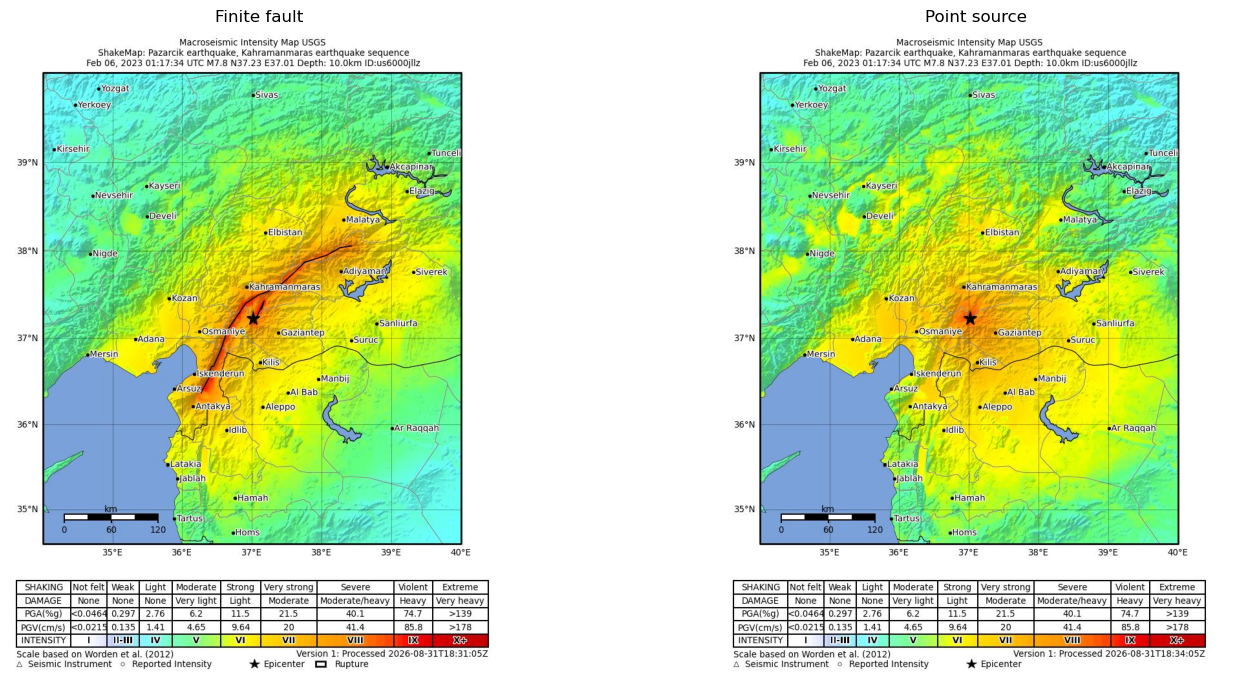

In [ ]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step3_pointsource_grid.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step3_grid.xml')
step3_products = Path.home() / 'step3_products'
if step3_products.exists(): shutil.rmtree(step3_products)
shutil.copytree(PRODUCTS, step3_products)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, path, title in [
    (axes[0], Path.home() / 'step2_FF_grid.jpg',         'Finite fault'),
    (axes[1], Path.home() / 'step3_pointsource_grid.jpg', 'Point source'),
]:
    ax.imshow(mpimg.imread(path)); ax.set_title(title, fontsize=12); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Points mode — predict shaking at station locations

Restore the finite fault and run ShakeMap in points mode, predicting shaking
at the locations of the 262 seismic stations.

Show the stationlist.json so it's clearer how we extract 

In [ ]:
if rupture_bak.exists():
    rupture_bak.rename(EVENT_DIR / 'rupture.json')
    print('rupture.json restored')
with open(EVENT_CFG / 'stationlist.json') as f:
    stations = json.load(f)
rows = []
for feat in stations['features']:
    props = feat['properties']
    if props.get('network', '').upper() == 'DYFI':
        continue
    lon, lat = feat['geometry']['coordinates'][:2]
    network = props.get('network', 'XX')
    code_str = props.get('code', f'STA{len(rows):04d}')
    station_id = f'{network}.{code_str}' if '.' not in code_str else code_str
    rows.append({'id': station_id, 'lat': lat, 'lon': lon})
sites_df = pd.DataFrame(rows)
sites_csv = EVENT_DIR / 'sites.csv'
sites_df.to_csv(sites_csv, index=False)
print(f'Wrote {len(rows)} seismic station locations to sites.csv')
print(sites_df['id'].head(3))
check_event_inputs()

rupture.json restored
Wrote 262 seismic station locations to sites.csv
0    KO.ARPRA
1     KO.CMRD
2     KO.KHMN
Name: id, dtype: str
Current event inputs:
  event.xml: ✓
  rupture.json: ✓
  stationlist.json: —
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


We run the shake command with the -p argument to provide points data file to 'assemble' command.

In [13]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -p ~/shakemap_profiles/default/data/$EVENT/current/sites.csv \
  -c 'points mode FF' model

INFO -- 2026-08-31 18:37:53 -- shake.main -- Running command assemble
INFO -- 2026-08-31 18:37:53 -- shake.main -- Finished running command assemble: Elapsed 0.05 secs
INFO -- 2026-08-31 18:37:53 -- shake.main -- Running command model
INFO -- 2026-08-31 18:37:53 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:37:53 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:37:56 -- shake.main -- Finished running command model: Elapsed 2.55 secs
INFO -- 2026-08-31 18:37:56 -- shake.main -- shake finished with event us6000jllz


If makecsv is called with the -g (--generate-stationlist) argument, instead of creating a CSV file it will create a file stationlist.json that is suitable for input to ShakeMap via assemble.

In [15]:
%%bash
export EVENT=us6000jllz
shake $EVENT makecsv -g

INFO -- 2026-08-31 18:39:58 -- shake.main -- Running command makecsv
INFO -- 2026-08-31 18:39:58 -- shake.main -- Finished running command makecsv: Elapsed 0.08 secs
INFO -- 2026-08-31 18:39:58 -- shake.main -- shake finished with event us6000jllz


No we verify the file was created.

In [16]:
synthetic_files = glob.glob(str(PRODUCTS / '*points*.json'))
print('Generated files:', synthetic_files)

Generated files: ['/home/vscode/shakemap_profiles/default/data/us6000jllz/current/products/us6000jllz_points_GREATER_OF_TWO_HORIZONTAL.json']


## 6. Grid mode — point source + FF-predicted stations

We next remove the rupture and use the synthetic station data from the points mode run.

In [17]:
rupture = EVENT_DIR / 'rupture.json'
rupture_bak = EVENT_DIR / 'rupture.json.bak'
if rupture.exists():
    rupture.rename(rupture_bak)
    print('rupture.json moved — point source mode')
if synthetic_files:
    shutil.copy(synthetic_files[0], EVENT_DIR / 'stationlist.json')
    print(f'Copied {Path(synthetic_files[0]).name} as stationlist.json')
check_event_inputs()

rupture.json moved — point source mode
Copied us6000jllz_points_GREATER_OF_TWO_HORIZONTAL.json as stationlist.json
Current event inputs:
  event.xml: ✓
  rupture.json: —
  stationlist.json: ✓
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


In [18]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid PS + FF stations' model contour mapping gridxml

INFO -- 2026-08-31 18:43:06 -- shake.main -- Running command assemble
INFO -- 2026-08-31 18:43:06 -- shake.main -- Finished running command assemble: Elapsed 0.05 secs
INFO -- 2026-08-31 18:43:06 -- shake.main -- Running command model
INFO -- 2026-08-31 18:43:06 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:43:06 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)


INFO -- 2026-08-31 18:43:06 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 18:43:06 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-31 18:43:06 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-31 18:43:26 -- shake.main -- Finished running command model: Elapsed 20.71 secs
INFO -- 2026-08-31 18:43:26 -- shake.main -- Running command contour
INFO -- 2026-08-31 18:43:28 -- shake.main -- Finished running command contour: Elapsed 1.44 secs
INFO -- 2026-08-31 18:43:28 -- shake.main -- Running command mapping
INFO -- 2026-08-31 18:43:50 -- shake.main -- Finished running command mapping: Elapsed 21.78 secs
INFO -- 2026-08-31 18:43:50 -- shake.main -- Running command gridxml
INFO -- 2026-08-31 18:43:51 -- shake.main -- Finished running command gridxml: Elapsed 0.79 secs
INFO -- 2026-08-31 18:43:51 -- shake.main -- shake finished with event us6000jllz


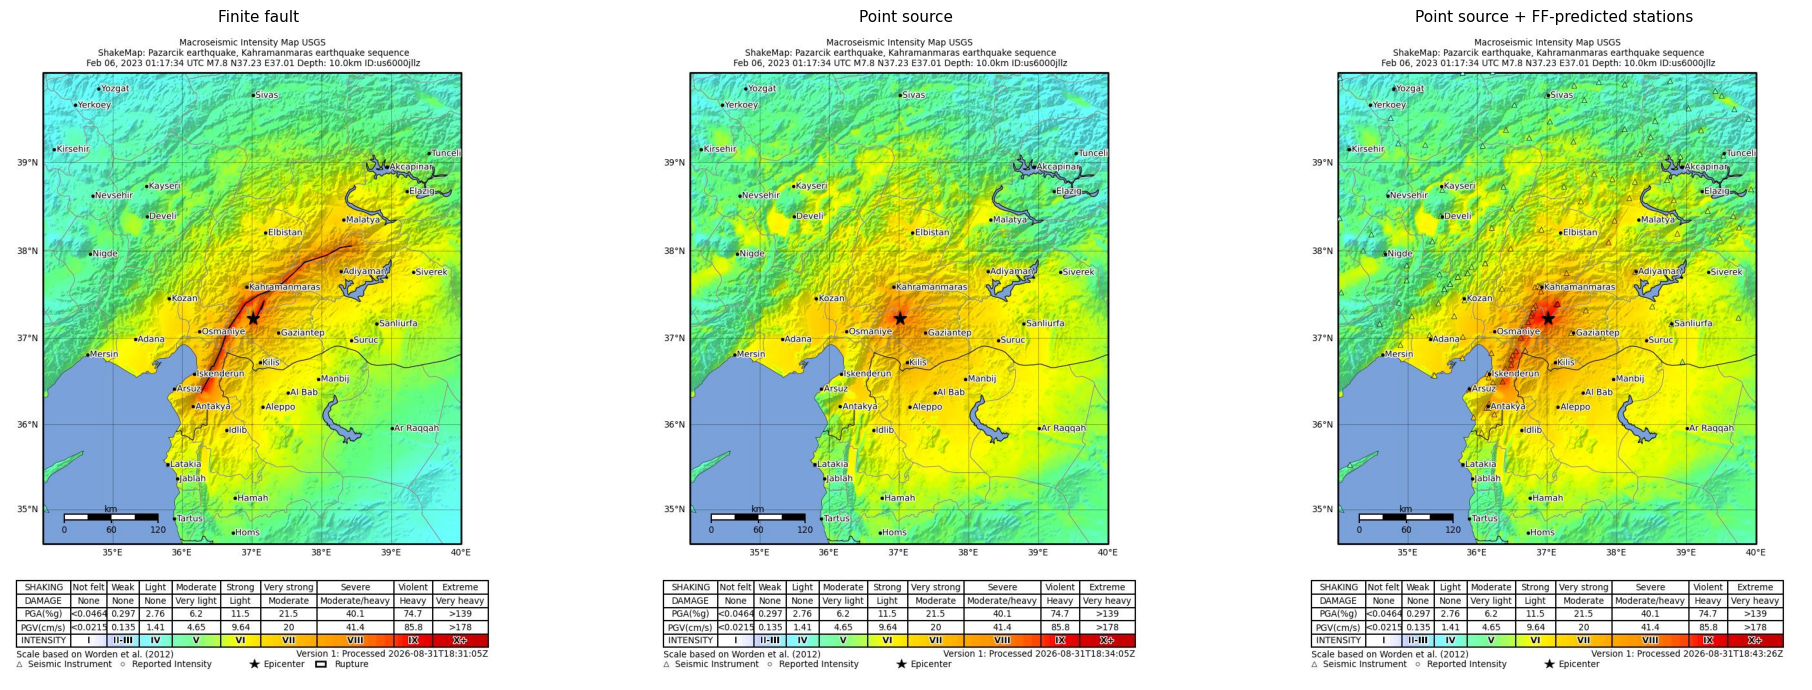

In [19]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step4_ps_ffstations.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step4_grid.xml')
step4_products = Path.home() / 'step4_products'
if step4_products.exists(): shutil.rmtree(step4_products)
shutil.copytree(PRODUCTS, step4_products)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, path, title in [
    (axes[0], Path.home() / 'step2_FF_grid.jpg',         'Finite fault'),
    (axes[1], Path.home() / 'step3_pointsource_grid.jpg', 'Point source'),
    (axes[2], Path.home() / 'step4_ps_ffstations.jpg',   'Point source + FF-predicted stations'),
]:
    ax.imshow(mpimg.imread(path)); ax.set_title(title, fontsize=11); ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Grid mode — point source + real observations

We next use the actual 262 station observations (which were downloaded using sm_create earlier in the notebook).

In [20]:
for f in ['stationlist.json']:
    p = EVENT_DIR / f
    if p.exists(): p.unlink()
shutil.copy(EVENT_CFG / 'stationlist.json', EVENT_DIR / 'stationlist.json')
print('Real stationlist.json copied')
check_event_inputs()

Real stationlist.json copied
Current event inputs:
  event.xml: ✓
  rupture.json: —
  stationlist.json: ✓
  instrumented_dat.json: —
  dyfi_dat.json: —
  sites.csv: ✓


In [21]:
%%bash
export EVENT=us6000jllz
shake $EVENT assemble -c 'grid FF + real stations' model contour mapping gridxml

INFO -- 2026-08-31 18:45:55 -- shake.main -- Running command assemble
INFO -- 2026-08-31 18:45:55 -- shake.main -- Finished running command assemble: Elapsed 0.27 secs
INFO -- 2026-08-31 18:45:55 -- shake.main -- Running command model
INFO -- 2026-08-31 18:45:55 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:45:55 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:45:55 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 18:45:55 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-31 18:45:55 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)


INFO -- 2026-08-31 18:46:22 -- shake.main -- Finished running command model: Elapsed 26.82 secs
INFO -- 2026-08-31 18:46:22 -- shake.main -- Running command contour
INFO -- 2026-08-31 18:46:24 -- shake.main -- Finished running command contour: Elapsed 1.52 secs
INFO -- 2026-08-31 18:46:24 -- shake.main -- Running command mapping
INFO -- 2026-08-31 18:46:45 -- shake.main -- Finished running command mapping: Elapsed 21.84 secs
INFO -- 2026-08-31 18:46:45 -- shake.main -- Running command gridxml
INFO -- 2026-08-31 18:46:46 -- shake.main -- Finished running command gridxml: Elapsed 0.75 secs
INFO -- 2026-08-31 18:46:46 -- shake.main -- shake finished with event us6000jllz


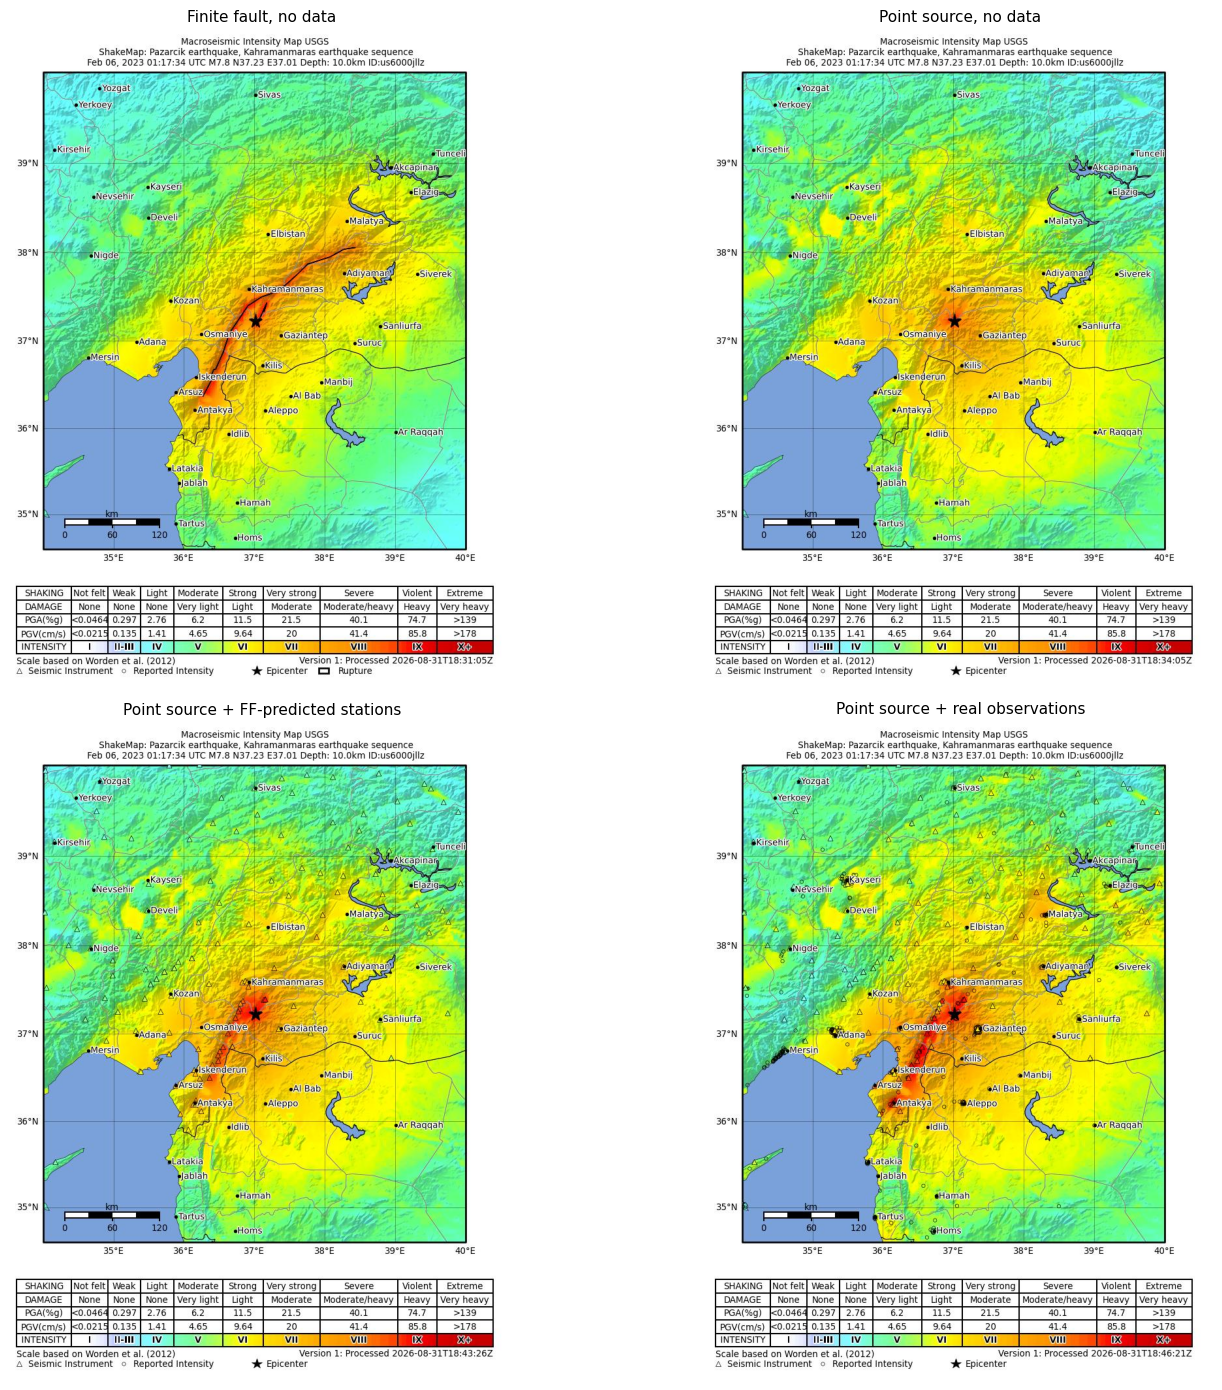

In [22]:
shutil.copy(PRODUCTS / 'intensity.jpg', Path.home() / 'step5_real_stations.jpg')
shutil.copy(PRODUCTS / 'grid.xml',      Path.home() / 'step5_grid.xml')
step5_products = Path.home() / 'step5_products'
if step5_products.exists(): shutil.rmtree(step5_products)
shutil.copytree(PRODUCTS, step5_products)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, path, title in [
    (axes[0,0], Path.home() / 'step2_FF_grid.jpg',         'Finite fault, no data'),
    (axes[0,1], Path.home() / 'step3_pointsource_grid.jpg', 'Point source, no data'),
    (axes[1,0], Path.home() / 'step4_ps_ffstations.jpg',   'Point source + FF-predicted stations'),
    (axes[1,1], Path.home() / 'step5_real_stations.jpg',   'Point source + real observations'),
]:
    ax.imshow(mpimg.imread(path)); ax.set_title(title, fontsize=11); ax.axis('off')
plt.tight_layout(); plt.show()

As an exercise you can run the ShakeMap with further variations if you like.

## 8. Shaking statistics comparison

In [23]:
stats = {}
for label, grid_path in [
    ('Step 2: FF, no data',          Path.home() / 'step2_grid.xml'),
    ('Step 3: Point source, no data', Path.home() / 'step3_grid.xml'),
    ('Step 4: PS + FF stations',      Path.home() / 'step4_grid.xml'),
    ('Step 5: PS + real stations',    Path.home() / 'step5_grid.xml'),
]:
    if grid_path.exists():
        stats[label] = get_shakemap_stats(grid_path)
pd.DataFrame(stats).T

,Max MMI,Area MMI≥VII (km²),Area MMI≥VIII (km²),Area MMI≥IX (km²)
"Step 2: FF, no data",9.0,"16,320","3,787",4
"Step 3: Point source, no data",8.6,"9,651",769,0
Step 4: PS + FF stations,9.1,"16,708","2,758",44
Step 5: PS + real stations,9.4,"23,105","5,120",344


## 9. Discussion

- How does the finite fault change the spatial pattern of shaking?
- Does the FF-predicted station data improve the point source?
- Where do real observations change the ShakeMap most?

---
## 10. Exercise: What if only part of the fault ruptured?

In [ ]:
# Show how to do this with quad rupture

In [3]:
%%bash
sm_rupture -h

usage: sm_rupture [-h] [-f FILE] [-e EVENTFILE] [-o]
                  [--format {shakemap3,fsp,neic,json}]
                  outfile

Create a ShakeMap 4 rupture.json file from a ShakeMap 3 *_fault.txt file, an
FSP file, a NEIC finite fault file, or an existing rupture.json file. If no
input file is provided, the user will be prompted to manually input rupture
data (strike, dip, ...). Note that the rupture.json requires some origin
information that is not in the fault.txt file and so these values are filled
in with empty values unless an event.xml file is also provided.

positional arguments:
  outfile               Path for output rupture file.

options:
  -h, --help            show this help message and exit
  -f FILE, --file FILE  Path to ShakeMap 3 fault file.
  -e EVENTFILE, --eventfile EVENTFILE
                        Path to an event.xml file.
  -o, --old             Indicates that the ShakeMap 3 fault fileuses the old
                        format (ordering lon before lat).


In [ ]:
# What is a reasonable magnitude for this rupture?

We can use the QuadRupture class to create the rupture in Python directly.
However we can also use the sm_rupture as an alternative way to construct the rupture.

In [24]:
%%bash
sm_rupture -e ~/shakemap_profiles/default/data/us6000jllz/current/event.xml \
    ~/shakemap_profiles/default/data/us6000jllz/current/partial_rupture.json << 'EOF'
Partial rupture — 30 km segment near epicenter
1
1
37.01
37.23
0
0
0
30
15
65
90
EOF


* No fault file specified. You will be prompted to manually enter rupture
information.

You will need to specify the number of quadrilaterals in the rupture. Each
quadrilateral will be defined with the following geometry:

                            strike direction
                        p1*------------------->>p2
                        *        | dy           |
                 dip    |--------o              |
              direction |   dx    known point   | Width
                        V                       |
                        V                       |
                        p4----------------------p3
                                Length

  - Rupture reference?   - How many quadrilaterals are in this rupture?   Quad 1 of 1...
  - Input method:
    (1) Orientation parameters (strike/dip/length/width)
    (2) Four vertices (lon/lat/depth)
  Choice:     Longitude of known point:     Latitude of known point:     Depth (km) of known point:     Along-strike distance (km) 

In [ ]:
# check the partial rupture magnitude. (update event.xml)

In [26]:
from pathlib import Path

EVENT = 'us6000jllz'
EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'

for f in ['stationlist.json', 'instrumented_dat.json', 'dyfi_dat.json']:
    p = EVENT_DIR / f
    if p.exists():
        p.unlink()
        print(f'Removed {f}')
    else:
        print(f'{f} not present')

stationlist.json not present
instrumented_dat.json not present
dyfi_dat.json not present


In [27]:
%%bash
export EVENT=us6000jllz
cp ~/shakemap_profiles/default/data/us6000jllz/current/partial_rupture.json \
   ~/shakemap_profiles/default/data/us6000jllz/current/rupture.json
shake $EVENT assemble -c 'partial rupture' model contour mapping gridxml

INFO -- 2026-08-31 18:52:26 -- shake.main -- Running command assemble
INFO -- 2026-08-31 18:52:26 -- shake.main -- Finished running command assemble: Elapsed 0.03 secs
INFO -- 2026-08-31 18:52:26 -- shake.main -- Running command model
INFO -- 2026-08-31 18:52:26 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:52:26 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 18:52:26 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 18:52:26 -- output_grid._adjust_resolution -- Updated dx: 0.022611 (degrees)
INFO -- 2026-08-31 18:52:26 -- output_grid._adjust_resolution -- Updated dy: 0.0179864 (degrees)
INFO -- 2026-08-31 18:52:30 -- shake.main -- Finished running command model: Elapsed 4.27 secs
INFO -- 2026-08-31 18:52:30 -- shake.main -- Running command contour
INFO -- 2026-08-31 18:52:31 -- shake.main --

INFO -- 2026-08-31 18:52:52 -- shake.main -- Finished running command mapping: Elapsed 21.10 secs
INFO -- 2026-08-31 18:52:52 -- shake.main -- Running command gridxml
INFO -- 2026-08-31 18:52:53 -- shake.main -- Finished running command gridxml: Elapsed 0.68 secs
INFO -- 2026-08-31 18:52:53 -- shake.main -- shake finished with event us6000jllz


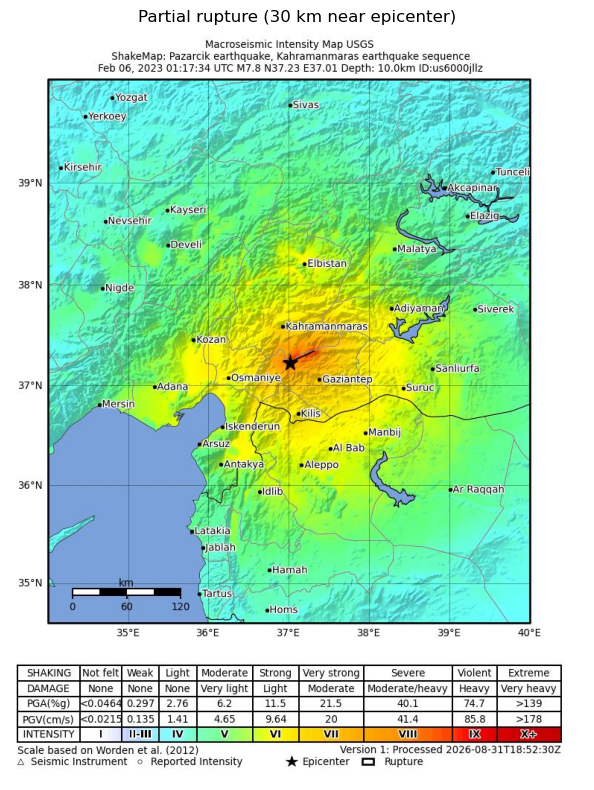

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(mpimg.imread(str(PRODUCTS / 'intensity.jpg')))
ax.set_title('Partial rupture (30 km near epicenter)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

### Ground failure: full rupture vs. partial rupture

How does the shorter (30 km) rupture change the landslide and liquefaction hazard, compared to the full finite fault?

In [29]:
%%bash
export EVENT=us6000jllz

# Set the default paths and output directory
export DEFAULTCONFIGPATH=/home/vscode/groundfailure/defaultconfigfiles/models
/opt/conda/envs/gf/bin/gfailbin --set-default-paths -c $DEFAULTCONFIGPATH
# Make two output directories to keep partial and full ruptures separate
export OUTDIRP=/home/vscode/gf_output/partial
mkdir $OUTDIRP -p
export OUTDIRF=/home/vscode/gf_output/full
mkdir $OUTDIRF -p

# Run gfailbin for the partial rupture
/opt/conda/envs/gf/bin/gfailbin \
  /workspaces/shakemap-gf-workshop/data/gf_configs_turkey_global.txt \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis -w \
  -d /workspaces/shakemap-gf-workshop/data/turkey_inputs \
  -pf /workspaces/shakemap-gf-workshop/data/turkey_inputs/ghsl_pop_tur_2025.tif \
  -a partial \
  -o $OUTDIRP

# Also run gfailbin for the full rupture you ran earlier (the ShakeMap grid.xml file was copied over)
/opt/conda/envs/gf/bin/gfailbin \
  /workspaces/shakemap-gf-workshop/data/gf_configs_turkey_global.txt \
  /home/vscode/step2_grid.xml \
  --gis -w \
  -d /workspaces/shakemap-gf-workshop/data/turkey_inputs \
  -pf /workspaces/shakemap-gf-workshop/data/turkey_inputs/ghsl_pop_tur_2025.tif \
  -o $OUTDIRF

New default paths set.

Default paths currently set to:

	output_filepath = /home/vscode/gf_output
	config_filepath = /home/vscode/groundfailure/defaultconfigfiles/models
default paths set, continuing...


Running the following models:
	jessee_2018_slim
	zhu_2017_general_slim
Applying bounds of lonmin 34.00, lonmax 40.01, latmin 34.58, latmax 40.00

Now running jessee_2018_slim:

The following input layers do not cover the area of interest:
	/workspaces/shakemap-gf-workshop/data/turkey_inputs/Jessee2018_X.tif
	/workspaces/shakemap-gf-workshop/data/turkey_inputs/jessee_standard_deviation.tif
Running model for new bounds that are fully covered by input layer: 34.05, 39.961600000000004, 35.86944444444443, 39.95

Now running zhu_2017_general_slim:

The following input layers do not cover the area of interest:
	/workspaces/shakemap-gf-workshop/data/turkey_inputs/Zhu2017_general_X.tif
	/workspaces/shakemap-gf-workshop/data/turkey_inputs/zhu2017_standard_deviation.tif
Running model for new bo


Files created:

/home/vscode/gf_output/partial/us6000jllz/shakefile.txt
us6000jllz_jessee_2018_slim_partial.hdf5
/home/vscode/gf_output/partial/us6000jllz/us6000jllz_jessee_2018_slim_partial_model.tif
/home/vscode/gf_output/partial/us6000jllz/us6000jllz_jessee_2018_slim_partial_model.kmz
us6000jllz_zhu_2017_general_slim_partial.hdf5
/home/vscode/gf_output/partial/us6000jllz/us6000jllz_zhu_2017_general_slim_partial_model.tif
/home/vscode/gf_output/partial/us6000jllz/us6000jllz_zhu_2017_general_slim_partial_model.kmz
['/home/vscode/gf_output/partial/us6000jllz/jessee_2018_extent.json', '/home/vscode/gf_output/partial/us6000jllz/zhu_2017_general_extent.json', '/home/vscode/gf_output/partial/us6000jllz/zhu_2017_general.png']
['/home/vscode/gf_output/partial/us6000jllz/info.json']

Running the following models:
	jessee_2018_slim
	zhu_2017_general_slim
Applying bounds of lonmin 34.00, lonmax 40.01, latmin 34.58, latmax 40.00

Now running jessee_2018_slim:

The following input layers do not 

In [30]:
%%bash
export OUTDIRP=/home/vscode/gf_output/partial
export EVENT=us6000jllz
M=$HOME/groundfailure/defaultconfigfiles/models
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee 2018:$OUTDIRP/$EVENT/${EVENT}_jessee_2018_slim_partial_model.tif:$M/jessee_2018_slim.ini" \
  --model "Zhu 2017:$OUTDIRP/$EVENT/${EVENT}_zhu_2017_general_slim_partial_model.tif:$M/zhu_2017_general_slim.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --infojson  $OUTDIRP/info.json \
  --outfile ~/turkey_gf_partial.html

Reading /home/vscode/gf_output/partial/us6000jllz/us6000jllz_jessee_2018_slim_partial_model.tif...
Reading /home/vscode/gf_output/partial/us6000jllz/us6000jllz_zhu_2017_general_slim_partial_model.tif...
Saved: /home/vscode/turkey_gf_partial.html
[Jessee 2018] max P: 0.2173, area>0.002: 5.8%
[Zhu 2017] max P: 0.3725, area>0.005: 14.1%


In [31]:
import base64
from IPython.display import HTML
html_path = Path.home() / 'turkey_gf_partial.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


#### Side by side landslide model 
Let's look at the Landslide model for the shorter rupture vs the original rupture side by side. Note, this will only work if you already ran the 02 notebook

In [32]:
%%bash
export EVENT=us6000jllz
export OUTDIRP=/home/vscode/gf_output/partial
export OUTDIRF=/home/vscode/gf_output/full
M=$HOME/groundfailure/defaultconfigfiles/models

/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee 2018 (Partial rupture):$OUTDIRP/$EVENT/${EVENT}_jessee_2018_slim_partial_model.tif:$M/jessee_2018_slim.ini" \
  --model "Jessee 2018 (Full rupture):$OUTDIRF/$EVENT/${EVENT}_jessee_2018_slim_model.tif:$M/jessee_2018_slim.ini"  \
  --outfile ~/turkey_gf_sidebyside.html



Reading /home/vscode/gf_output/partial/us6000jllz/us6000jllz_jessee_2018_slim_partial_model.tif...
Reading /home/vscode/gf_output/full/us6000jllz/us6000jllz_jessee_2018_slim_model.tif...
Saved: /home/vscode/turkey_gf_sidebyside.html
[Jessee 2018 (Partial rupture)] max P: 0.2173, area>0.002: 5.8%
[Jessee 2018 (Full rupture)] max P: 0.2252, area>0.002: 12.7%


In [33]:
import base64
from IPython.display import HTML
html_path = Path.home() / 'turkey_gf_sidebyside.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [100]:
shutil.copy(EVENT_CFG / 'rupture.json', EVENT_DIR / 'rupture.json')
print('Full rupture.json restored')

Full rupture.json restored


**Discussion:**
- Which cities lose significant shaking when only part of the fault ruptures?